## 3. Data Preparation

Two rules govern every feature in this table:

- **Leakage-aware lags.** Every macro predictor enters as a *lag*, never contemporaneously, due to a forecast made "as of" quarter $t$ only sees data that would genuinely have been published by then (`src/features.py`).
- **Documented interventions, not silent dummies.** Structural breaks (GST, COVID) are
  captured as named dummy columns with a cited reason and a genuine forecast-lead-time
  count — not fitted after the fact to explain away a residual.

In [1]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
for _ in range(4):
    if (PROJECT_ROOT / "reports").is_dir() and (PROJECT_ROOT / "data").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = (
    "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6",
)
BLUE, PLUM, MUTED, ALERT = "#5b6f8f", "#8a4f8a", "#9aa79f", "#c0392b"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 11, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

import matplotlib.dates as mdates

def year_axis(ax, step=5):
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

CURATED = PROJECT_ROOT / "data" / "curated" / "quarterly_macro_features.csv"
TABLEAU = PROJECT_ROOT / "reports" / "tableau"

In practice that rule is a per-series assumption, from `data/metadata/series_availability.csv`: market-observed series are usable the moment they are set, while survey and statistical-agency series are only trusted one quarter after the fact.

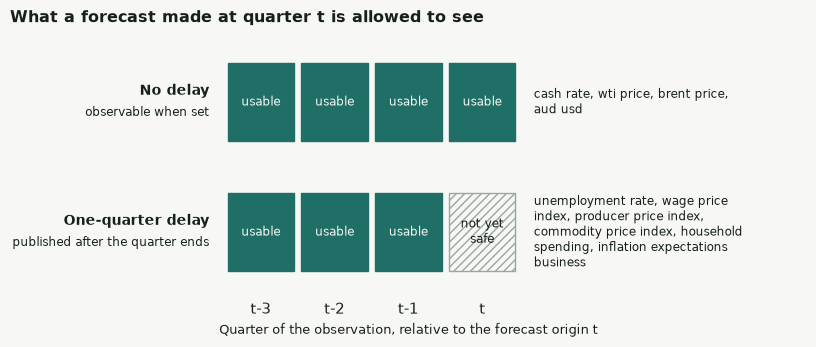

In [2]:
import textwrap

avail = pd.read_csv(PROJECT_ROOT / "data/metadata/series_availability.csv")
avail = avail[~avail["source_family"].str.startswith("derived")]          # base series only
groups = {
    0: ("No delay", "observable when set"),
    1: ("One-quarter delay", "published after the quarter ends"),
}
steps = [-3, -2, -1, 0]                                                   # quarters relative to origin t
fig, ax = plt.subplots(figsize=(8.6, 3.6))
for row, lag in enumerate([0, 1]):
    y = 1 - row
    names = ", ".join(avail.loc[avail["assumed_min_safe_lag_quarters"] == lag, "variable"]).replace("_", " ")
    for x in steps:
        usable = x <= -lag
        ax.add_patch(plt.Rectangle((x - 0.45, y - 0.30), 0.9, 0.6,
                                   facecolor=ACCENT if usable else PAPER,
                                   edgecolor=ACCENT if usable else MUTED,
                                   hatch=None if usable else "////", linewidth=1))
        ax.text(x, y, "usable" if usable else "not yet\nsafe", ha="center", va="center", fontsize=8.5,
                color=PAPER if usable else INK)
    title, sub = groups[lag]
    ax.text(-3.7, y + 0.03, title, ha="right", va="bottom", fontsize=10, fontweight="bold")
    ax.text(-3.7, y - 0.03, sub, ha="right", va="top", fontsize=8.5)
    ax.text(0.7, y, "\n".join(textwrap.wrap(names, 34)), ha="left", va="center", fontsize=8.5)
ax.set_xlim(-6.4, 4.4); ax.set_ylim(-0.5, 1.55)
ax.set_xticks(steps, ["t-3", "t-2", "t-1", "t"])
ax.set_xlabel("Quarter of the observation, relative to the forecast origin t", fontsize=9.5)
ax.set_yticks([]); ax.grid(False)
for s in ("left", "bottom"):
    ax.spines[s].set_visible(False)
ax.tick_params(axis="x", length=0)
ax.set_title("What a forecast made at quarter t is allowed to see", loc="left", fontsize=11.5, fontweight="bold")
fig.tight_layout()
plt.show()

**A caveat on "as of" data.** The leakage-aware lag rule above is real and enforced in code, but it rests on a transparent assumption set rather than an audited real-time record: the curated dataset is built from revised historical ABS/RBA/market data, which reflecting the values statistical agencies publish today for past quarters, rather than true real-time release vintages or the values that would genuinely have been available on each historical publication date. `data/metadata/series_availability.csv` documents the lag assumption used for each series, but a genuine real-time vintage archive would be needed to fully audit it.

*Source: [Appendix §9 — Leakage And Forecast-Origin Availability Assumptions](appendix_eda/09_leakage_availability)*

**Related appendix sections.** Which macro features actually survive into Elastic Net, and why regularizing them matters, is covered in detail in the appendix:

- [§8 Multicollinearity And VIF](appendix_eda/08_multicollinearity_vif): only `wpi_growth_lag2` crosses the VIF=10 threshold (12.7), with `inflation_expectations_business_lag1` close behind (9.6) — real but moderate redundancy among the external macro features, which is the concrete justification for Elastic Net's $\ell_2$ penalty.
- [§10 Candidate Exogenous Feature Screening — headline](appendix_eda/10_exogenous_screening_headline): nine features survive screening, led by `inflation_expectations_business_lag1`, `ppi_growth_lag2`, and the cash-rate lags — a shortlist, not the final feature set, which is still chosen by walk-forward RMSE in §4.2.
- [§11 Candidate Exogenous Feature Screening — trimmed mean](appendix_eda/11_exogenous_screening_trimmed_mean): re-running the screen on `trimmed_mean_cpi_yoy` surfaces a materially different mix — inflation-expectations and cash-rate correlations weaken sharply while commodity/oil-price features move to the front — which is why the trimmed-mean Elastic Net block leads with the oil and commodity terms (it keeps the weaker expectations and cash-rate terms too, and lets regularization weigh them).

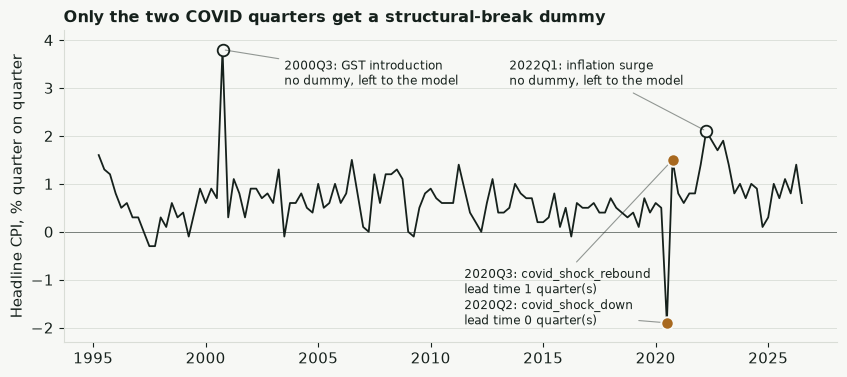

In [3]:
df = pd.read_csv(CURATED)
df = df.dropna(subset=["cpi_qoq"])
df["date"] = pd.PeriodIndex(df["quarter"], freq="Q").to_timestamp(how="end")
interventions = pd.read_csv(PROJECT_ROOT / "data/metadata/intervention_quarters.csv")
dummied = df[df["quarter"].isin(interventions["quarter"])].merge(
    interventions[["quarter", "dummy_name", "lead_quarters"]], on="quarter")
gst = df[df["quarter"] == "2000Q3"].iloc[0]
surge = df[df["date"] >= "2021-06-30"].nlargest(1, "cpi_qoq").iloc[0]      # peak of the 2021-23 surge

fig, ax = plt.subplots(figsize=(8.6, 3.9))
ax.axhline(0, color=INK, linewidth=0.7, alpha=0.5)
ax.plot(df["date"], df["cpi_qoq"], color=INK, linewidth=1.3)
ax.scatter([gst["date"], surge["date"]], [gst["cpi_qoq"], surge["cpi_qoq"]], s=70, facecolor=PAPER,
           edgecolor=INK, linewidth=1.3, zorder=3)
ax.scatter(dummied["date"], dummied["cpi_qoq"], s=80, color=HIGHLIGHT, edgecolor=PAPER, linewidth=1.4, zorder=4)

leader = dict(arrowstyle="-", color=INK, alpha=0.45, linewidth=0.8)
ax.annotate("2000Q3: GST introduction\nno dummy, left to the model", (gst["date"], gst["cpi_qoq"]),
            xytext=(pd.Timestamp("2003-06-30"), 3.3), fontsize=8.3, va="center", arrowprops=leader)
ax.annotate(f"{surge['quarter']}: inflation surge\nno dummy, left to the model", (surge["date"], surge["cpi_qoq"]),
            xytext=(pd.Timestamp("2013-06-30"), 3.3), fontsize=8.3, va="center", arrowprops=leader)
for _, r in dummied.iterrows():
    down = r["cpi_qoq"] < 0
    ax.annotate(f"{r['quarter']}: {r['dummy_name']}\nlead time {int(r['lead_quarters'])} quarter(s)",
                (r["date"], r["cpi_qoq"]),
                xytext=(pd.Timestamp("2011-06-30"), -1.7 if down else -1.05), fontsize=8.3, va="center",
                arrowprops=leader)
ax.set_ylim(-2.3, 4.2)
ax.set_ylabel("Headline CPI, % quarter on quarter")
ax.set_title("Only the two COVID quarters get a structural-break dummy", loc="left", fontsize=11.5, fontweight="bold")
ax.grid(axis="x", visible=False)
year_axis(ax, 5)
fig.tight_layout()
plt.show()

**Interpretation.** Only two structural breaks get a named dummy, both from the 2020
COVID shock: `covid_shock_down` (2020Q2, CPI's largest quarterly fall on record) and
`covid_shock_rebound` (2020Q3, its largest rise in 20 years). The `lead_quarters` column
shows the leakage-aware rule applied even to the dummies themselves — `covid_shock_down` is
available with zero lead (the fall was already visible within the reference quarter), while
`covid_shock_rebound` carries a one-quarter lead, since by the time it's used as a predictor
for a *future* forecast, the prior quarter's rebound is already known. Neither the GST
introduction (1999-2000) nor the 2022-23 inflation surge gets a dummy — those episodes are
left for the models (and the [§3 CPI Target Inspection z-score screen](appendix_eda/03_cpi_target_inspection))
to explain through their own dynamics rather than being assumed away.


**A note on where else "the COVID shock" appears.** These two dummies are defined on the
raw quarter-on-quarter CPI print. The [§4.4 SVAR](04_modeling/44_svar) shock-location
export (`reports/tableau/svar_shock_events.csv`) does *not* flag `2020Q2`/`2020Q3` — it
z-scores the structural shock to the **year-on-year** `cpi_yoy`/`trimmed_mean_cpi_yoy`
series instead, fit full-sample with no COVID dummy or exclusion. A YoY series smooths the
2020 level shock across four quarters, so the same event only reads as statistically
unusual a year later, once the depressed 2020 base drops out of the comparison — which is
why that export instead flags `2021Q2`/`2021Q3`. Same event, two different transforms of
CPI, not a discrepancy between the two artifacts.